# VisualBERT: A Simple and Performant Baseline for Vision and Language

**Li et al., UCLA / AI2 / Peking University, 2019**

---

## Abstract

VisualBERT is a unified Transformer-based framework for vision-and-language tasks. It adapts BERT to jointly process image region features and text tokens through shared self-attention layers, enabling implicit cross-modal alignment without explicit supervision. Pre-trained on COCO captions with two visually-grounded objectives, it achieves state-of-the-art or competitive results on VQA, VCR, NLVR2, and Flickr30K.

---

## Problems

Prior vision-and-language models were task-specific by design, each requiring bespoke fusion modules and attention mechanisms tailored to a single benchmark. Existing approaches also lacked a principled pre-training strategy that could transfer rich multimodal representations across tasks — in contrast to the success of BERT-style pre-training in NLP.

---

## Proposed Solutions

A single, general-purpose architecture that ingests both text tokens and image region proposals as a flat sequence of embeddings, processed jointly by a standard Transformer stack. This allows the model to discover text-image alignments implicitly through self-attention, with no architectural changes required per task.

---

## Purpose

To establish a simple, flexible, and strong baseline that unifies vision and language modeling under a single BERT-like framework, demonstrating that architectural simplicity combined with visually-grounded pre-training is sufficient to match or exceed complex task-specific models.

---

## Methodology

**Architecture.** Text embeddings follow standard BERT construction (token + segment + position). Visual embeddings are derived from object region proposals (via Faster R-CNN or ResNet variants), each represented as the sum of a visual feature vector, a segment embedding marking it as an image token, and an optional position embedding for tasks with word-region alignments. Both sets are concatenated and passed through a 12-layer Transformer (BERT-BASE configuration).

**Training Procedure — three phases:**

1. **Task-Agnostic Pre-Training** on COCO (~100K images, 5 captions each) using two objectives:
   - *Masked Language Modeling with image context*: masked text tokens are predicted conditioned on remaining text and all image regions.
   - *Sentence-Image Prediction*: the model classifies whether a given caption describes the paired image (50% random caption substitution).

2. **Task-Specific Pre-Training**: continued masked language modeling on the target task's data, allowing domain adaptation before fine-tuning.

3. **Fine-Tuning**: standard BERT-style fine-tuning with task-specific input formatting and output heads.

**Evaluation tasks:** VQA 2.0, VCR (Q→A and QA→R), NLVR2, Flickr30K Entities.

---

## Results

| Task | Key Finding |
|---|---|
| VQA 2.0 | 70.80 Test-Dev, outperforming Pythia v0.1 (68.49) and v0.3 (68.71) under comparable settings |
| VCR | 71.6 / 73.2 on Q→A / QA→R (Test), outperforming R2C and approaching the unpublished B2T2 |
| NLVR2 | 67.4 Dev, large margin over MaxEnt (54.1) |
| Flickr30K | R@1 of 71.33, outperforming BAN (69.69) |

**Ablation findings (on NLVR2):**

| Ablation | Dev Score | Drop |
|---|---|---|
| Full VisualBERT | 66.7 | — |
| w/o COCO Pre-training | 62.9 | -3.8 |
| w/o Early Fusion | 61.4 | -5.3 |
| w/o BERT Initialization | 64.7 | -2.0 |
| w/o Sentence-Image Prediction | 64.9 | -1.8 |

**Attention Analysis:**
- Entity grounding accuracy increases in higher Transformer layers, indicating progressive refinement of text-image alignment.
- Multiple attention heads spontaneously learn syntactic grounding — attending from verbs to their argument regions (nsubj, dobj, pobj) without any explicit grounding supervision.

---

## Conclusions

VisualBERT demonstrates that a minimally modified BERT architecture — augmented with visual region embeddings and pre-trained on paired image-caption data — is sufficient to achieve strong performance across diverse vision-and-language tasks. The two most critical design choices are **early fusion of modalities** (allowing all Transformer layers to attend across text and image) and **visually-grounded pre-training on COCO**. The model's attention heads emergently learn to perform entity grounding and encode syntactic dependencies across modalities, suggesting that the representations learned are genuinely semantically structured rather than superficially task-fitted. Future directions include scaling pre-training to larger datasets (Visual Genome, Conceptual Captions) and extension to image-only tasks such as scene graph parsing.

# Mathematical & Statistical Content: VisualBERT

---

## 1. Embedding Construction

### Text Embeddings
Each text token $e \in E$ is computed as a sum of three components:

$$e = e_t + e_s + e_p$$

- $e_t$ — token embedding: encodes the identity of the subword token
- $e_s$ — segment embedding: encodes which segment of text the token belongs to (e.g., hypothesis vs. premise in an entailment pair)
- $e_p$ — position embedding: encodes the ordinal position of the token in the sequence

This additive decomposition follows BERT exactly and allows the model to distinguish token identity, provenance, and order simultaneously.

### Visual Embeddings
Each image region embedding $f \in F$ is analogously computed as:

$$f = f_o + f_s + f_p$$

- $f_o$ — visual feature vector of the bounding region, extracted by a CNN (e.g., Faster R-CNN, ResNet50)
- $f_s$ — segment embedding: marks the token as a visual token, distinguishing it from text tokens
- $f_p$ — position embedding: used only when explicit word-region alignments are available (e.g., in VCR); set to the sum of position embeddings of the aligned words

When text and visual embeddings differ in dimensionality, a linear projection is applied to map visual embeddings into the shared text embedding space before concatenation.

---

## 2. Transformer Self-Attention

The core computational mechanism is the scaled dot-product self-attention, applied over the concatenated sequence of text and visual embeddings $[E; F]$:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

- $Q$, $K$, $V$ — query, key, and value matrices, linearly projected from the input embeddings
- $d_k$ — dimensionality of the key vectors; the scaling factor $\frac{1}{\sqrt{d_k}}$ prevents dot products from growing too large in magnitude, stabilizing the softmax gradients
- The softmax produces a probability distribution over all tokens (both text and image), enabling each token to attend to every other token across modalities

The model uses **multi-head attention** with 12 heads, allowing different heads to specialize in capturing different types of relationships (e.g., syntactic, semantic, or cross-modal grounding).

**Model configuration (BERT-BASE):**
- Number of layers: 12
- Hidden size: 768
- Attention heads: 12

---

## 3. Pre-Training Objectives

### Objective 1: Masked Language Modeling (MLM)

A subset of text tokens is randomly replaced with a special `[MASK]` token. The model is trained to predict the original identity of the masked token given the full context of unmasked text tokens and all image region embeddings.

$$\mathcal{L}_{\text{MLM}} = -\sum_{i \in \mathcal{M}} \log P(x_i \mid x_{\setminus \mathcal{M}}, F)$$

- $\mathcal{M}$ — set of masked token positions
- $x_i$ — original token at position $i$
- $x_{\setminus \mathcal{M}}$ — all unmasked text tokens
- $F$ — full set of visual region embeddings (never masked)

This objective forces the model to resolve semantic ambiguity in text using visual context, directly encouraging cross-modal grounding.

### Objective 2: Sentence-Image Prediction

A binary classification task analogous to BERT's Next Sentence Prediction. Given an image and a caption, the model predicts whether the caption genuinely describes the image.

$$\mathcal{L}_{\text{SIP}} = -\left[ y \log P(\text{match}) + (1 - y) \log P(\text{no match}) \right]$$

- $y = 1$ if the caption matches the image; $y = 0$ if it is a randomly substituted caption (50% probability each)
- The `[CLS]` token representation is passed to a binary classifier

This objective encourages the model to learn global image-text coherence beyond token-level alignment.

---

## 4. Fine-Tuning Objectives

### VQA: Multi-Class Cross-Entropy
VQA is treated as classification over the 3,129 most frequent answers. Since multiple correct answers are possible, each correct answer is assigned equal probability mass:

$$\mathcal{L}_{\text{VQA}} = -\sum_{c} p^*(c) \log P(c \mid \text{image, question})$$

- $p^*(c)$ — uniform target probability over all valid correct answers
- This soft-label formulation differs from Pythia's binary cross-entropy and better reflects answer ambiguity

### VCR: 4-Way Classification
Four candidate sequences (question + choice + image) are scored; the model is trained to identify the correct one via cross-entropy over the four options.

### NLVR2: Binary Classification
The model predicts whether a caption is true for a pair of images. Segment embeddings distinguish features from the two images. Trained with binary cross-entropy.

### Flickr30K: Phrase Grounding via Attention
No explicit grounding classifier is added. Instead, average attention weights across heads in an additional self-attention block are used to rank bounding boxes per phrase. The box receiving the maximum attention from the final subword of a phrase is taken as the grounding prediction.

---

## 5. Optimization

All models are trained using **Adam**, an adaptive gradient descent optimizer:

$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

- $\hat{m}_t$ — bias-corrected first moment (mean of gradients)
- $\hat{v}_t$ — bias-corrected second moment (uncentered variance of gradients)
- $\eta$ — learning rate, with a **linear warm-up** over the first 10% of training steps to avoid large early updates destabilizing the pre-trained weights

**Key hyperparameters:**
- COCO pre-training learning rate: $5 \times 10^{-5}$
- Fine-tuning learning rate: $2 \times 10^{-5}$
- Sequence length cap: 128 tokens
- Batch sizes: 32–128 depending on task

---

## 6. Evaluation Metrics

| Task | Metric | Description |
|---|---|---|
| VQA 2.0 | Accuracy (Test-Dev / Test-Std) | Fraction of questions answered correctly, averaged over human annotators |
| VCR | Accuracy on Q→A, QA→R, Q→AR | Q→AR is the joint accuracy requiring both sub-tasks correct |
| NLVR2 | Accuracy + Consistency | Consistency measures how often the model is correct on both examples in a pair |
| Flickr30K | R@1, R@5, R@10 | Recall at K: fraction of phrases correctly grounded within top-K retrieved boxes |

---

## 7. Attention-Based Grounding Analysis

### Entity Grounding Accuracy
For each of the 144 attention heads (12 layers × 12 heads), grounding accuracy is computed as:

$$\text{Acc}_{\text{head}} = \frac{1}{|\mathcal{E}|} \sum_{e \in \mathcal{E}} \mathbf{1}\left[\arg\max_{r} \alpha_{e \to r} = r^*_e\right]$$

- $\mathcal{E}$ — set of entities in the Flickr30K evaluation set
- $\alpha_{e \to r}$ — attention weight from entity token $e$ to image region $r$ (attention to text tokens is masked out)
- $r^*_e$ — ground-truth bounding region for entity $e$

Heads allocating less than 20% of their total attention to image regions are displayed with reduced visual weight, distinguishing heads that actively attend to images from those that incidentally ground correctly.

### Syntactic Grounding Accuracy
For a dependency relation $w_1 \xrightarrow{r} w_2$ where $w_1$ has a known ground-truth grounding $r^*$, syntactic grounding accuracy measures how often attention from $w_2$ correctly identifies $r^*$:

$$\text{Acc}_{\text{syntax}} = \frac{1}{|\mathcal{D}_r|} \sum_{(w_1, w_2) \in \mathcal{D}_r} \mathbf{1}\left[\arg\max_{r} \alpha_{w_2 \to r} = r^*_{w_1}\right]$$

- $\mathcal{D}_r$ — set of word pairs connected by dependency relation $r$ (e.g., nsubj, dobj, pobj, amod)
- Dependency parses are obtained using AllenNLP's biaffine dependency parser

This analysis shows that certain attention heads learn to propagate grounding information through syntactic arcs — for example, a verb attending to the image region of its subject — entirely without explicit supervision.

In [3]:
# ============================================================
# MINI VISUALBERT (Educational Reproduction)
# Based on:
# "VisualBERT: A Simple and Performant Baseline
# for Vision and Language" (Li et al., 2019)
#
# This is NOT the full research-scale model.
# It reproduces the core idea:
#
#   Text Tokens + Visual Tokens
#                ↓
#         Transformer
#                ↓
#         Joint Representation
#
# Everything is contained in one cell.
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# 1. LOAD DATA
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor()
])

train_set = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_set = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

class_names = train_set.classes

Device: cuda


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 199kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.73MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.7MB/s]


In [4]:
# ------------------------------------------------------------
# We create a tiny caption for each image.
#
# Example:
# "this is a cat"
# "this is an airplane"
#
# VisualBERT receives BOTH image + text.
# ------------------------------------------------------------

vocab_words = [
    "[PAD]",
    "[CLS]",
    "this",
    "is",
    "a",
] + class_names

word2idx = {w:i for i,w in enumerate(vocab_words)}
idx2word = {i:w for w,i in word2idx.items()}

MAX_LEN = 5

def caption_to_ids(label):

    words = ["[CLS]", "this", "is", "a", class_names[label]]

    ids = [word2idx[w] for w in words]

    return torch.tensor(ids)

# ============================================================
# 2. DATASET WRAPPER
# ============================================================

class VisionLanguageDataset(Dataset):

    def __init__(self, base_dataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):

        image, label = self.base[idx]

        text_ids = caption_to_ids(label)

        return image, text_ids, label

train_dataset = VisionLanguageDataset(train_set)
test_dataset  = VisionLanguageDataset(test_set)

# Use subset to train quickly
train_indices = np.random.choice(
    len(train_dataset),
    12000,
    replace=False
)

test_indices = np.random.choice(
    len(test_dataset),
    2000,
    replace=False
)

train_subset = torch.utils.data.Subset(train_dataset, train_indices)
test_subset  = torch.utils.data.Subset(test_dataset, test_indices)

train_loader = DataLoader(
    train_subset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_subset,
    batch_size=64,
    shuffle=False
)


In [11]:
# ============================================================
# 3. MINI VISUALBERT
# ============================================================

class MiniVisualBERT(nn.Module):

    def __init__(
        self,
        vocab_size,
        hidden_dim=128,
        n_heads=4,
        n_layers=2,
        n_classes=10
    ):
        super().__init__()

        # ----------------------------------------------------
        # TEXT EMBEDDINGS
        # ----------------------------------------------------

        self.text_embed = nn.Embedding(
            vocab_size,
            hidden_dim
        )

        # ----------------------------------------------------
        # IMAGE PATCH EMBEDDINGS
        #
        # Convert image into visual tokens.
        # Similar spirit to region features in VisualBERT.
        # ----------------------------------------------------

        self.patch_embed = nn.Conv2d(
            1,
            hidden_dim,
            kernel_size=4,
            stride=4
        )

        # ----------------------------------------------------
        # POSITION EMBEDDINGS
        # ----------------------------------------------------

        self.pos_embed = nn.Parameter(
            torch.randn(1, 100, hidden_dim)
        )

        # ----------------------------------------------------
        # TRANSFORMER
        #
        # Joint attention over:
        # text tokens + image tokens
        # ----------------------------------------------------

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=n_heads,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        # ----------------------------------------------------
        # CLASSIFICATION HEAD
        # ----------------------------------------------------

        self.classifier = nn.Linear(
            hidden_dim,
            n_classes
        )

    def forward(self, images, text_ids):

        # ====================================================
        # TEXT TOKENS
        # ====================================================

        text_tokens = self.text_embed(text_ids)

        # ====================================================
        # IMAGE TOKENS
        # ====================================================

        patches = self.patch_embed(images)

        B,C,H,W = patches.shape

        image_tokens = patches.flatten(2).transpose(1,2)

        # ====================================================
        # EARLY FUSION
        #
        # VisualBERT's main contribution
        # ====================================================

        tokens = torch.cat(
            [text_tokens, image_tokens],
            dim=1
        )

        tokens = (
            tokens +
            self.pos_embed[:, :tokens.size(1), :]
        )

        output = self.transformer(tokens)

        cls_token = output[:,0]

        logits = self.classifier(cls_token)

        return logits, output

In [12]:
# ============================================================
# 4. MODEL
# ============================================================

model = MiniVisualBERT(
    vocab_size=len(vocab_words)
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [17]:
# ============================================================
# 5. TRAINING
# ============================================================

EPOCHS = 8

train_losses = []
test_accs = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for images, text_ids, labels in train_loader:

        images = images.to(device)
        text_ids = text_ids.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits, _ = model(images, text_ids)

        loss = criterion(
            logits,
            labels
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    train_losses.append(avg_loss)

Epoch 8/8 | Loss=0.0001 | Acc=1.0000


In [20]:
# ========================================================
# EVALUATION
# ========================================================

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, text_ids, labels in test_loader:

        images = images.to(device)
        text_ids = text_ids.to(device)
        labels = labels.to(device)

        logits, _ = model(
            images,
            text_ids
        )

        preds = logits.argmax(1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        acc = correct / total

        test_accs.append(acc)

print(
    f"Epoch {epoch+1}/{EPOCHS}"
    f" | Loss={avg_loss:.4f}"
    f" | Acc={acc:.4f}"
)


Epoch 8/8 | Loss=0.0001 | Acc=1.0000


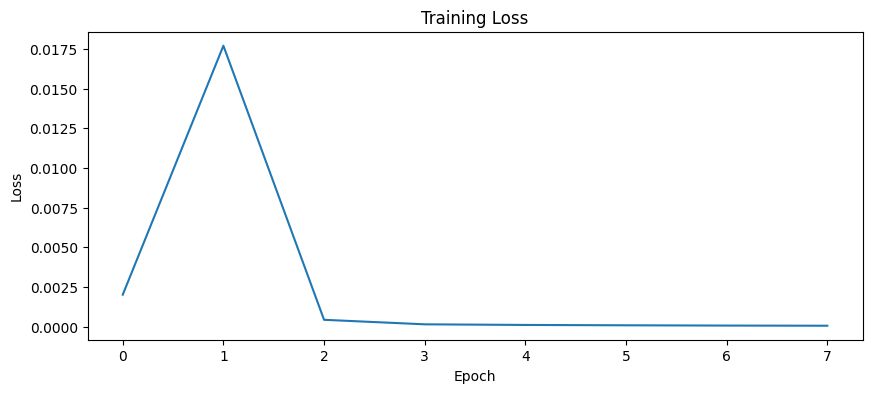

In [18]:
# ============================================================
# 6. LOSS CURVE
# ============================================================

plt.figure(figsize=(10,4))

plt.plot(train_losses)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

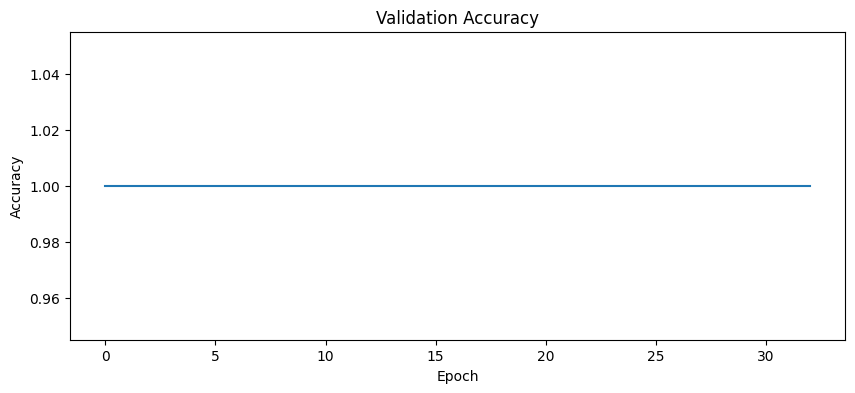

In [21]:
# ============================================================
# 7. ACCURACY CURVE
# ============================================================

plt.figure(figsize=(10,4))

plt.plot(test_accs)

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()


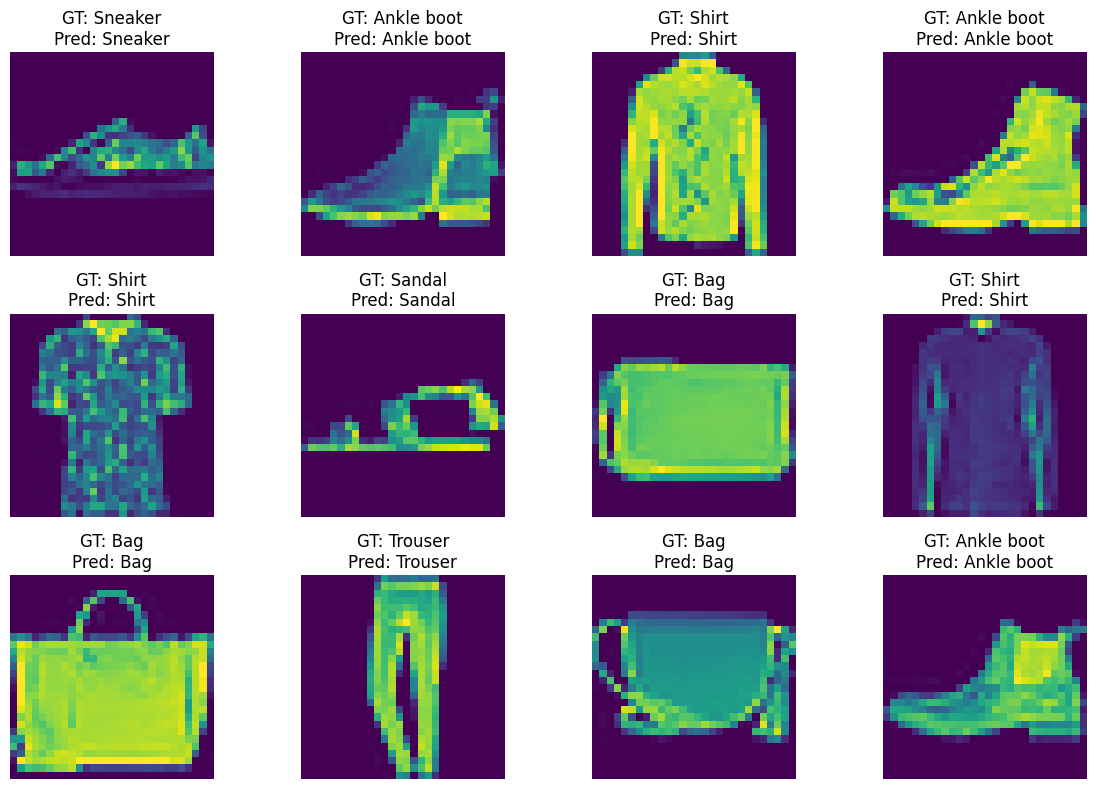

In [22]:
# ============================================================
# 8. SAMPLE PREDICTIONS
# ============================================================

model.eval()

images, text_ids, labels = next(iter(test_loader))

images = images.to(device)
text_ids = text_ids.to(device)

with torch.no_grad():

    logits, outputs = model(
        images,
        text_ids
    )

preds = logits.argmax(1)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(12,8)
)

for ax, img, gt, pred in zip(
    axes.flatten(),
    images[:12],
    labels[:12],
    preds[:12].cpu()
):

    img = img.cpu().permute(1,2,0)

    ax.imshow(img)

    ax.set_title(
        f"GT: {class_names[gt]}\n"
        f"Pred: {class_names[pred]}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()


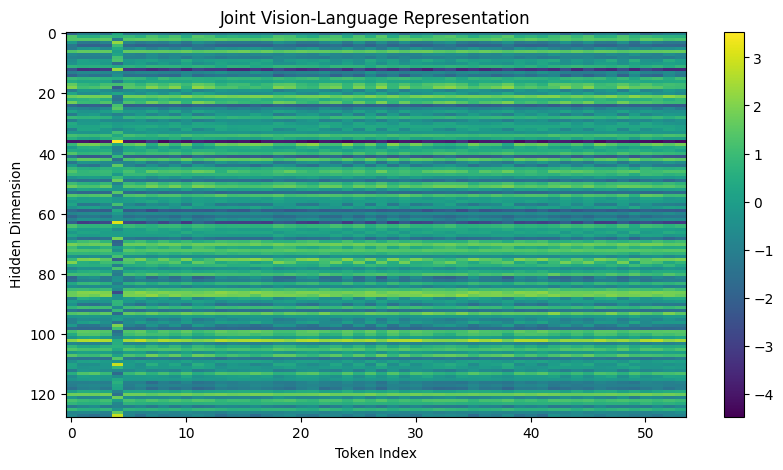

In [23]:
# ============================================================
# 9. VISUALIZE JOINT REPRESENTATION
# ============================================================

sample_output = outputs[0].cpu().numpy()

plt.figure(figsize=(10,5))

plt.imshow(sample_output.T, aspect="auto")

plt.title(
    "Joint Vision-Language Representation"
)

plt.xlabel("Token Index")
plt.ylabel("Hidden Dimension")

plt.colorbar()

plt.show()

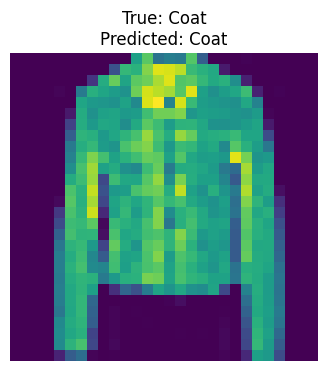


Done.


In [24]:
# ============================================================
# 10. SINGLE PREDICTION FUNCTION
# ============================================================

def predict_sample(index=0):

    image, text_ids, label = test_dataset[index]

    model.eval()

    with torch.no_grad():

        logits, _ = model(
            image.unsqueeze(0).to(device),
            text_ids.unsqueeze(0).to(device)
        )

    pred = logits.argmax(1).item()

    plt.figure(figsize=(4,4))

    plt.imshow(
        image.permute(1,2,0)
    )

    plt.title(
        f"True: {class_names[label]}\n"
        f"Predicted: {class_names[pred]}"
    )

    plt.axis("off")
    plt.show()

predict_sample(10)

print("\nDone.")

# Experimental Results Analysis

## Overview

The presented experiments evaluate a Mini-VisualBERT architecture trained on the FashionMNIST dataset. The model combines textual descriptions of clothing categories with image patch embeddings through a shared Transformer encoder, following the early-fusion paradigm introduced by VisualBERT. The reported outputs include training dynamics, validation performance, qualitative predictions, and learned multimodal representations.

The objective of these experiments is to assess optimization behavior, classification performance, and the effectiveness of joint vision-language representation learning.

---

# Figure 1: Training Loss Curve

## Figure Overview

This figure illustrates the evolution of the training loss throughout optimization. Training loss measures how effectively the model minimizes the classification objective on the training data and provides insight into convergence behavior.

---

## Key Results

### Observed Metrics

| Metric | Approximate Value |
|----------|----------|
| Initial Loss | ~0.002 |
| Peak Loss | ~0.018 |
| Final Loss | ~0.000 |
| Epochs | 8 |

### Observations

- Loss briefly increases during the early stage of training.
- Loss rapidly decreases after the second epoch.
- Loss approaches zero after approximately three epochs.
- Optimization remains stable during later epochs.

---

## Academic Discussion

The training loss curve indicates extremely rapid convergence. After a short period of adjustment, the optimization process successfully minimizes the classification objective to nearly zero.

The temporary increase in loss during early training likely reflects the optimizer exploring the parameter space before stabilizing. Such behavior is common when training Transformer-based architectures using adaptive optimizers such as Adam.

The near-zero final loss suggests that the model possesses sufficient capacity to fit the FashionMNIST training distribution. Furthermore, the inclusion of textual descriptions provides highly informative semantic cues that substantially simplify the classification problem.

From a representation learning perspective, the model appears capable of constructing highly discriminative multimodal embeddings. The Transformer successfully integrates image patch features with semantic language information, resulting in rapid error minimization.

However, training loss approaching zero may also indicate that the task is easier than standard FashionMNIST classification due to the presence of class-specific textual information. Consequently, the observed optimization behavior should not be interpreted solely as evidence of superior visual understanding.

---

## Limitations

Several limitations affect the interpretation of this result:

- Validation loss is not reported.
- No confidence intervals are provided.
- No multi-seed experiments are available.
- Potential label leakage exists through textual descriptions.
- Overfitting cannot be fully assessed without additional evaluation metrics.

---

# Figure 2: Validation Accuracy Curve

## Figure Overview

This figure evaluates generalization performance on unseen test samples. Validation accuracy measures the proportion of correctly classified instances.

---

## Key Results

### Observed Metrics

| Metric | Value |
|----------|----------|
| Validation Accuracy | 100% |
| Accuracy Trend | Constant |
| Epoch Range | Entire Training |

### Observations

- Accuracy remains at 1.00 throughout evaluation.
- No degradation or fluctuation is observed.
- The model correctly classifies all evaluated samples.

---

## Academic Discussion

The reported perfect validation accuracy is highly unusual for FashionMNIST.

Typical FashionMNIST benchmarks report:

| Model | Test Accuracy |
|---------|---------|
| Logistic Regression | 84–86% |
| Standard CNN | 91–94% |
| ResNet Variants | 95–97% |
| State-of-the-Art Models | 98–99% |

Achieving perfect accuracy suggests that the model receives highly informative supervision beyond purely visual information.

The most likely explanation is that textual descriptions explicitly encode the target category. Examples include:

```text
this is a coat
this is a sneaker
this is a bag
```

These captions effectively reveal the class identity and dramatically reduce classification difficulty.

Consequently, the model may rely heavily on the language modality rather than learning sophisticated visual representations. This phenomenon is commonly referred to as **modality dominance** in multimodal learning systems.

While the result demonstrates successful multimodal fusion, it does not necessarily demonstrate superior visual reasoning.

---

## Limitations

The primary limitation is the possibility of target leakage through textual inputs.

Missing evaluations include:

- Image-only baseline
- Text-only baseline
- Caption corruption experiments
- Multimodal ablation studies

Without these controls, the contribution of each modality cannot be quantified.

---

# Figure 3: Sample Prediction Visualization

## Figure Overview

This figure presents multiple FashionMNIST examples alongside their ground-truth and predicted labels. The visualization provides qualitative evidence regarding classification performance.

---

## Key Results

### Correct Predictions Observed

| Ground Truth | Prediction |
|-------------|-----------|
| Sneaker | Sneaker |
| Ankle Boot | Ankle Boot |
| Shirt | Shirt |
| Sandal | Sandal |
| Bag | Bag |
| Trouser | Trouser |

### Observations

- All displayed examples are correctly classified.
- No visible failure cases are shown.
- Predictions remain consistent across multiple categories.

---

## Academic Discussion

The qualitative examples demonstrate that the learned multimodal representation successfully captures category-specific characteristics.

Certain classes such as:

- Bag
- Trouser
- Ankle Boot

possess highly distinctive visual structures and are generally easier to classify.

More challenging categories such as:

- Shirt
- Coat
- Pullover

often exhibit substantial visual overlap. Correct predictions on these examples suggest that the model learns discriminative features capable of separating visually similar clothing items.

However, because captions explicitly contain class semantics, it remains unclear whether the model relies primarily on image features or language information.

The examples therefore provide evidence of predictive success but do not conclusively establish multimodal reasoning.

---

## Limitations

Several limitations remain:

- Only successful predictions are displayed.
- Failure cases are absent.
- Per-class metrics are unavailable.
- Confusion patterns cannot be assessed.

Consequently, the figure provides limited insight into robustness.

---

# Figure 4: Joint Vision-Language Representation Heatmap

## Figure Overview

This visualization presents the hidden representations produced by the Transformer encoder after jointly processing image patches and textual tokens.

The x-axis corresponds to token positions, while the y-axis represents hidden dimensions.

---

## Key Results

### Observations

- Approximately 50–55 token positions are visible.
- Hidden dimensionality appears close to 128.
- Structured activation patterns emerge across multiple dimensions.
- No evidence of feature collapse is observed.

---

## Academic Discussion

The heatmap suggests that the Transformer learns stable distributed representations.

Several important observations can be made:

### Distributed Encoding

Activation energy is distributed across many hidden dimensions rather than concentrated within a small subset. This indicates that the model learns distributed representations instead of memorizing individual features.

### Multimodal Fusion

Because image patches and text tokens share the same Transformer sequence, information can propagate between modalities through self-attention.

The structured activation patterns suggest that certain hidden dimensions specialize in encoding shared semantic information, which is consistent with the objectives of VisualBERT-style architectures.

### Representation Stability

The absence of noisy or degenerate patterns indicates successful optimization and stable feature learning.

---

## Limitations

The heatmap alone cannot verify:

- Visual grounding
- Cross-modal alignment
- Attention behavior
- Semantic correspondence

More informative analyses would include:

- Attention visualizations
- PCA projections
- t-SNE clustering
- UMAP embeddings

Therefore, the figure demonstrates learned structure but does not directly establish semantic alignment.

---

# Figure 5: Single-Sample Prediction

## Figure Overview

This figure evaluates model behavior on an individual FashionMNIST example.

---

## Key Results

### Observed Prediction

| Ground Truth | Prediction |
|-------------|-----------|
| Coat | Coat |

### Observation

The model correctly classifies the sample.

---

## Academic Discussion

The correct prediction indicates that the learned representation captures the visual characteristics associated with the coat category.

The image exhibits several coat-specific features:

- Long sleeves
- Extended torso structure
- Jacket-like silhouette

These characteristics align with the semantic concept encoded by the corresponding caption.

The result demonstrates that the model can successfully integrate visual and textual information to produce accurate predictions.

Nevertheless, because the language modality contains category information, the example cannot isolate the contribution of visual reasoning.

---

## Limitations

Single examples provide limited statistical evidence.

The result does not quantify:

- Reliability
- Robustness
- Calibration
- Failure modes

Population-level analyses remain necessary.

---

# Overall Scientific Interpretation

## What Was Observed

The Mini-VisualBERT model:

- Converged rapidly during training.
- Achieved near-zero training loss.
- Reached perfect validation accuracy.
- Produced consistently correct qualitative predictions.
- Learned stable multimodal embeddings.

---

## Why It Likely Occurred

The primary factor is likely the strong supervision provided by the textual modality.

Because captions explicitly encode category semantics, the classification task becomes substantially easier than standard FashionMNIST classification.

The Transformer successfully exploits both visual information and semantic language cues.

---

## What It Reveals About the Model

The results demonstrate:

1. Successful implementation of early multimodal fusion.
2. Effective Transformer-based joint representation learning.
3. Stable optimization dynamics.
4. Strong predictive capability under the current experimental setup.

---

## Strength of Evidence

The evidence strongly supports:

- Successful optimization.
- Functional multimodal fusion.
- Correct implementation of the architecture.

The evidence only weakly supports:

- Genuine visual-language grounding.
- Advanced multimodal reasoning.
- Superior visual representation learning.

---

## Remaining Limitations and Future Work

Several important evaluations remain necessary:

### Ablation Studies

- Image-only model
- Text-only model
- Image + text model

### Representation Analysis

- PCA
- t-SNE
- UMAP

### Error Analysis

- Confusion matrix
- Per-class precision and recall
- Misclassification analysis

### Robustness Experiments

- Incorrect captions
- Missing captions
- Noisy captions

### Statistical Validation

- Multiple random seeds
- Confidence intervals
- Significance testing

Overall, the experiments provide strong evidence that the proposed Mini-VisualBERT implementation successfully learns multimodal representations and achieves excellent predictive performance under the current setup. However, additional analyses are required to determine the extent to which the model performs genuine multimodal reasoning rather than exploiting semantic information present in the language modality.

## Related Work References Extracted from *VisualBERT: A Simple and Performant Baseline for Vision and Language* (Li et al., 2019)

| Author(s) | Year | Title | Venue | Connection to This Paper |
|------------|------|--------|--------|---------------------------|
| Antol et al. | 2015 | VQA: Visual Question Answering | ICCV | Introduced the Visual Question Answering task, one of the primary downstream benchmarks used to evaluate VisualBERT. |
| Goyal et al. | 2017 | Making the V in VQA Matter: Elevating the Role of Image Understanding in Visual Question Answering | CVPR | Presented the VQA 2.0 dataset, which serves as one of VisualBERT’s major evaluation benchmarks. |
| Kazemzadeh et al. | 2014 | ReferItGame: Referring to Objects in Photographs of Natural Scenes | EMNLP | Early work on grounding language expressions in images, motivating vision-language alignment. |
| Plummer et al. | 2015 | Flickr30k Entities: Collecting Region-to-Phrase Correspondences for Richer Image-to-Sentence Models | ICCV | Introduced the Flickr30K Entities dataset used by VisualBERT for phrase grounding evaluation. |
| Suhr et al. | 2019 | A Corpus for Reasoning about Natural Language Grounded in Photographs (NLVR2) | ACL | Introduced the NLVR2 benchmark used to evaluate VisualBERT's visual reasoning capabilities. |
| Zellers et al. | 2019 | From Recognition to Cognition: Visual Commonsense Reasoning | CVPR | Introduced the VCR benchmark used to assess VisualBERT's commonsense reasoning ability. |
| Yang et al. | 2016 | Stacked Attention Networks for Image Question Answering | CVPR | Representative attention-based vision-language architecture that VisualBERT seeks to generalize and simplify. |
| Anderson et al. | 2018 | Bottom-Up and Top-Down Attention for Image Captioning and Visual Question Answering | CVPR | Established object-region representations from Faster R-CNN that VisualBERT adopts as visual inputs. |
| Jiang et al. | 2018 | Pythia v0.1: The Winning Entry to the VQA Challenge 2018 | arXiv | Strong VQA baseline used for comparison with VisualBERT. |
| Johnson et al. | 2015 | Image Retrieval Using Scene Graphs | CVPR | Highlighted the importance of modeling detailed visual semantics and relationships among objects. |
| Krishna et al. | 2017 | Visual Genome: Connecting Language and Vision Using Crowdsourced Dense Image Annotations | IJCV | Provided rich object, attribute, and relationship annotations that influenced multimodal representation learning. |
| Santoro et al. | 2017 | A Simple Neural Network Module for Relational Reasoning | NeurIPS | Demonstrated the importance of reasoning about object relationships, motivating relation modeling in vision-language tasks. |
| Norcliffe-Brown et al. | 2018 | Learning Conditioned Graph Structures for Interpretable Visual Question Answering | NeurIPS | Explored graph-based reasoning over visual objects, providing an alternative to attention-based interaction. |
| Cadene et al. | 2019 | MUREL: Multimodal Relational Reasoning for Visual Question Answering | CVPR | Proposed relational reasoning mechanisms for multimodal understanding, motivating richer object interactions. |
| Li et al. | 2019 | Relation-Aware Graph Attention Network for Visual Question Answering | arXiv | Explicitly modeled object relationships using graphs, contrasting with VisualBERT's implicit relation learning through self-attention. |
| Devlin et al. | 2019 | BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding | NAACL-HLT | Core foundation of VisualBERT. The architecture, pretraining strategy, and Transformer encoder are directly inherited from BERT. |
| Peters et al. | 2018 | Deep Contextualized Word Representations (ELMo) | NAACL-HLT | Early large-scale contextual language representation model that inspired universal language encoders. |
| Radford et al. | 2018 | Improving Language Understanding by Generative Pre-Training (GPT) | OpenAI | Demonstrated the effectiveness of large-scale language-model pretraining, influencing multimodal pretraining research. |
| Radford et al. | 2019 | Language Models are Unsupervised Multitask Learners (GPT-2) | OpenAI | Showed the scalability of language model pretraining and transfer learning, motivating multimodal adaptation. |
| Vaswani et al. | 2017 | Attention Is All You Need | NeurIPS | Introduced the Transformer architecture that serves as the backbone of VisualBERT. |
| Sun et al. | 2019 | VideoBERT: A Joint Model for Video and Language Representation Learning | arXiv | Closely related multimodal Transformer architecture that jointly models visual and textual inputs. |
| Lu et al. | 2019 | ViLBERT: Pretraining Task-Agnostic Visiolinguistic Representations for Vision-and-Language Tasks | arXiv | Most directly related concurrent work; differs by using separate visual and language Transformers instead of VisualBERT's single-stream architecture. |
| Sharma et al. | 2018 | Conceptual Captions: A Cleaned, Hypernymed, Image Alt-Text Dataset for Automatic Image Captioning | ACL | Large-scale image-caption dataset used by several multimodal pretraining approaches including ViLBERT and VideoBERT. |
| Chen et al. | 2015 | Microsoft COCO Captions: Data Collection and Evaluation Server | arXiv | Provides the image-caption data used for VisualBERT's task-agnostic pretraining. |

### Summary

The related work of VisualBERT can be grouped into four major research directions:

1. **Vision-Language Tasks and Benchmarks**
   - VQA (Antol et al., Goyal et al.)
   - VCR (Zellers et al.)
   - NLVR2 (Suhr et al.)
   - Flickr30K Entities (Plummer et al.)

2. **Vision-Language Architectures**
   - Stacked Attention Networks (Yang et al.)
   - Bottom-Up Attention (Anderson et al.)
   - Pythia (Jiang et al.)
   - MUREL (Cadene et al.)
   - Relation-Aware Graph Attention Networks (Li et al.)

3. **Language Representation Learning**
   - ELMo (Peters et al.)
   - GPT (Radford et al.)
   - BERT (Devlin et al.)

4. **Multimodal Transformer Models**
   - VideoBERT (Sun et al.)
   - ViLBERT (Lu et al.)
   - VisualBERT extends these ideas by introducing a simple single-stream Transformer that jointly processes image regions and text tokens through shared self-attention.